In [1]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from aijack.collaborative.fedavg import FedAVGClient, FedAVGServer, FedAVGAPI

In [2]:
#Hyperparameters
training_batch_size = 64
test_batch_size = 64
num_rounds = 5
lr = 0.001
seed = 0
client_size = 2
criterion = F.nll_loss


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def fix_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

fix_seed(seed)

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tawsifurrahman/covid19-radiography-database")

print("Path to dataset files:", path)

/Users/flaviafuscaldi/Desktop/fl_thesis/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/flaviafuscaldi/.cache/kagglehub/datasets/tawsifurrahman/covid19-radiography-database/versions/5


In [4]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np

# 1. Define Path (using the path from your kagglehub download)
data_dir = os.path.join(path, 'COVID-19_Radiography_Dataset')

# 2. Medical Transforms
# ResNet-18 expects 224x224 and specific normalization
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 3. Load full dataset
# ImageFolder looks for folders: 'COVID', 'Normal', etc.
full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)
print(f"Total images found: {len(full_dataset)}")
print(f"Classes: {full_dataset.classes}") # ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']

Total images found: 42330
Classes: ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']


In [5]:
def create_hospital_split(dataset, num_clients=2):
    # Get labels for all images
    labels = np.array(dataset.targets)
    client_indices = []
    
    # Hospital 0: Mostly COVID (Label 0) and Viral Pneumonia (Label 3)
    h0_indices = np.where((labels == 0) | (labels == 3))[0]
    # Hospital 1: Mostly Normal (Label 2) and Lung Opacity (Label 1)
    h1_indices = np.where((labels == 1) | (labels == 2))[0]
    
    return [h0_indices, h1_indices]

indices = create_hospital_split(full_dataset)
hospital_loaders = [DataLoader(Subset(full_dataset, i), batch_size=32, shuffle=True) for i in indices]

print(f"Hospital A (COVID/Pneumonia) size: {len(indices[0])}")
print(f"Hospital B (Normal/Opacity) size: {len(indices[1])}")

Hospital A (COVID/Pneumonia) size: 9922
Hospital B (Normal/Opacity) size: 32408


In [6]:
import torchvision.models as models
from aijack.attack.inversion import GradientInversion_Attack

# 1. Use ResNet-18 (The Medical Standard)
medical_net = models.resnet18(pretrained=True)
medical_net.fc = torch.nn.Linear(medical_net.fc.in_features, 4) # 4 classes
medical_net.to(device)

# 2. Setup the Spy Attack for 224x224 X-rays
medical_spy = GradientInversion_Attack(
    medical_net,
    x_shape=(3, 224, 224),
    num_iteration=3000, 
    lr=1.0, 
    optimizer_class=torch.optim.LBFGS, # LBFGS handles high-res better than SGD
    distancename="l2",
    tv_reg_coef=0.01 # This 'smooths' the lung edges in the reconstruction
)

/Users/flaviafuscaldi/Desktop/fl_thesis/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/flaviafuscaldi/Desktop/fl_thesis/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [7]:
import torchvision.models as models
from aijack.attack.inversion import GradientInversion_Attack

# 1. Use ResNet-18 (The Medical Standard)
medical_net = models.resnet18(pretrained=True)
medical_net.fc = torch.nn.Linear(medical_net.fc.in_features, 4) # 4 classes
medical_net.to(device)

# 2. Setup the Spy Attack for 224x224 X-rays
medical_spy = GradientInversion_Attack(
    medical_net,
    x_shape=(3, 224, 224),
    num_iteration=3000, 
    lr=1.0, 
    optimizer_class=torch.optim.LBFGS, # LBFGS handles high-res better than SGD
    distancename="l2",
    tv_reg_coef=0.01 # This 'smooths' the lung edges in the reconstruction
)

In [8]:
import torchvision.models as models

def get_medical_net(num_classes=4):
    # Load ResNet-18 with weights pre-trained on ImageNet
    model = models.resnet18(pretrained=True)
    # The original dataset has 4 classes: COVID, Normal, Lung_Opacity, Viral Pneumonia
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)

medical_net = get_medical_net()

In [9]:
from aijack.attack.inversion import GradientInversion_Attack

# 1. Define the Spy's Target Resolution (224x224 is the ResNet standard)
img_shape = (3, 224, 224)

# 2. Initialize the Hospital-Level Spy
medical_spy = GradientInversion_Attack(
    medical_net,
    x_shape=img_shape,
    num_iteration=500,       # LBFGS converges faster than SGD
    lr=1.0, 
    optimizer_class=torch.optim.LBFGS, 
    distancename="l2",
    # Total Variation (TV) is essential for medical images to reduce pixel noise
    tv_reg_coef=0.01, 
    l2_reg_coef=0.0001
)

In [10]:
import matplotlib.pyplot as plt

def plot_medical_comparison(original_tensor, reconstructed_tensor):
    # Move to CPU and denormalize for visualization
    def prepare(t):
        t = t.detach().cpu().squeeze().permute(1, 2, 0).numpy()
        # Simple clipping to valid image range [0, 1]
        return (t - t.min()) / (t.max() - t.min())

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    axes[0].imshow(prepare(original_tensor))
    axes[0].set_title("Original Patient X-Ray\n(At Hospital)")
    axes[0].axis("off")
    
    axes[1].imshow(prepare(reconstructed_tensor))
    axes[1].set_title("Reconstructed Scan\n(By Malicious Server)")
    axes[1].axis("off")
    
    plt.tight_layout()
    plt.show()

# After running result = medical_spy.group_attack(...)
# plot_medical_comparison(original_xray, result[0][0])

Reconstructing Medical Image (this may take a minute)...
worker_id=0: iter=10: 144.07691955566406, (best_iter=10: 144.07691955566406)
worker_id=1: iter=10: 141.22593688964844, (best_iter=9: 140.94461059570312)
worker_id=2: iter=10: 142.85191345214844, (best_iter=10: 142.85191345214844)
worker_id=3: iter=10: 144.274658203125, (best_iter=8: 143.14346313476562)
worker_id=4: iter=10: 143.56332397460938, (best_iter=7: 143.30455017089844)
worker_id=0: iter=20: 143.240966796875, (best_iter=17: 142.60023498535156)
worker_id=1: iter=20: 140.86178588867188, (best_iter=17: 140.10862731933594)
worker_id=2: iter=20: 141.425537109375, (best_iter=20: 141.425537109375)
worker_id=3: iter=20: 143.0505828857422, (best_iter=17: 142.70387268066406)
worker_id=4: iter=20: 141.7938995361328, (best_iter=20: 141.7938995361328)
worker_id=0: iter=30: 143.94741821289062, (best_iter=17: 142.60023498535156)
worker_id=1: iter=30: 140.04627990722656, (best_iter=25: 139.9951629638672)
worker_id=2: iter=30: 140.45230102

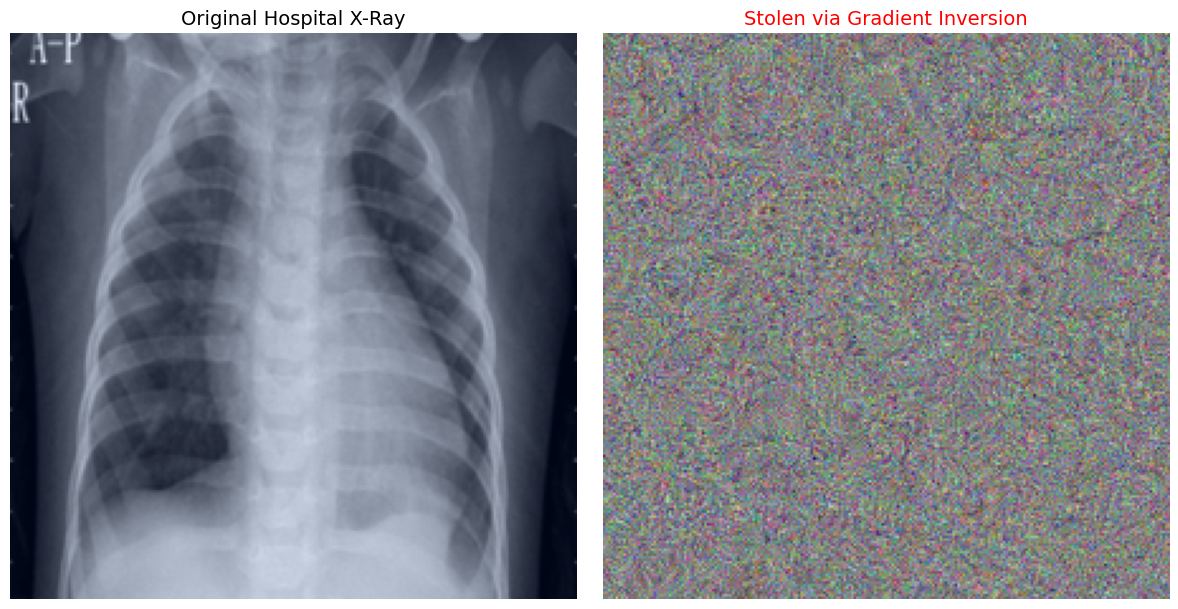

In [11]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

# 1. Grab a single real X-ray from your Hospital A loader
data_iter = iter(hospital_loaders[0])
images, labels = next(data_iter)
original_xray = images[0:1].to(device)  # Take 1 image (Batch size 1)
original_label = labels[0:1].to(device)

# 2. Generate the 'Victim' Gradient
medical_net.train()
output = medical_net(original_xray)
loss = nn.CrossEntropyLoss()(output, original_label)
target_grads = torch.autograd.grad(loss, medical_net.parameters())
target_grads = [g.detach() for g in target_grads]

# 3. Run the AIJack Reconstruction
print("Reconstructing Medical Image (this may take a minute)...")
# result[0][0] is the optimized dummy image
result = medical_spy.group_attack(target_grads, batch_size=1)
reconstructed_xray = result[0][0]

# 4. Plotting Function for the Thesis
def show_results(orig, recon):
    # Helper to convert tensor to viewable image
    def to_img(t):
        t = t.detach().cpu().squeeze().permute(1, 2, 0).numpy()
        t = (t - t.min()) / (t.max() - t.min()) # Normalize to [0, 1]
        return t

    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    
    ax[0].imshow(to_img(orig))
    ax[0].set_title("Original Hospital X-Ray", fontsize=14)
    ax[0].axis('off')
    
    ax[1].imshow(to_img(recon))
    ax[1].set_title("Stolen via Gradient Inversion", fontsize=14, color='red')
    ax[1].axis('off')
    
    plt.tight_layout()
    plt.show()

show_results(original_xray, reconstructed_xray)